# Multivariate TVLA : Higher-Order Analysis

⚠️ **Important:** This notebook assumes that the **Power Trace Acquisition** notebook has already been executed and the standard AES traceset has been acquired.

---

### 🔍 What is Multivariate TVLA and Why Do We Need It?

While **Univariate TVLA** looks for leakage at a single, isolated point in time (typical for hardware setups where multiple shares are processed simultaneously), **Multivariate TVLA** is required to detect higher-order leakage spread across *multiple distinct time samples*.

This is crucial for 
- **software implementations**, where a masking scheme processes different shares of intermediate values sequentially across different clock cycles
- **masked hardware implementations**, where traces are captured at a frequency higher than the device's clock frequency (meaning a single clock cycle is captured by multiple samples).

### 🛠️ The Methodology

To detect these spread-out leakages, a $d$-variate t-test combines multiple time points from a raw trace $X$ into a single "pseudo-trace" before testing.

For $d$ specific time indices ($t_1, \dots, t_d$), we calculate the mean $\mu(t_i)$ across all traces, and then compute the mean-free (centered) product. The new combined leakage value, $L_{comb}$, is:

$$L_{comb} = \prod_{i=1}^{d} (X(t_i) - \mu(t_i))$$

**The "Fork" Analogy:**
Imagine each trace as a timeline, and you're probing it with a multi-pronged fork:

* **1st-order (Univariate):** Single point probe `──────●─────────────────`
* **2nd-order (Bivariate):** Two-prong fork `──────●────────●────────`          
* **3rd-order (Trivariate):** Three-prong fork `──●────────●────────●───`       

Once the synthetic trace $L_{comb}$ is generated, we treat it as raw data and apply a standard 1st-order Welch's t-test directly to these combined values. A t-statistic exceeding the $\pm 4.5$ threshold indicates a detectable multivariate leakage.
With $d$-order analysis, the synthetic trace will be composed of $m-d$ samples

### ⚡ Implementation

In this notebook, we utilize the **`scalib`** library.
`scalib` provides an optimized, highly efficient multivariate TVLA function that handles the intensive centered-product trace combinations and higher-order statistical testing under the hood.

In [1]:
import os
from pathlib import Path
import h5py
import numpy as np
import scipy.stats as stats
from scalib.metrics import Ttest
import matplotlib.pyplot as plt

## 1. Configuration and Trace Loading
Load the ASCON power traces (*initialization phase only*) from the acquired HDF5 traceset and separate them into fixed and random datasets.

In [2]:
# Define paths and TVLA parameters
n_trc_captured = 2_000  # The total traces captured in the file
n_load = 1_000          # How many to actually load for the analysis per class

def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )

# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# Traces file path (board-captured traces)
TRACESET_DIR = DOJO_ROOT / "sw" / "traceset" / "ASCON" / "hw"
TRACESET_FILE = TRACESET_DIR / f"ascon_masked_{n_trc_captured // 1000}k_tvla.h5"

print(f"Loading traces from: {TRACESET_FILE}")

with h5py.File(TRACESET_FILE, 'r') as f:
    # Load all traces and labels into RAM
    all_traces = np.array(f['traces'])
    labels = np.array(f['labels'])

# Mask for fixed (0) and random (1), then slice exactly n_load of each
mask_fixed = (labels == 0)
mask_random = (labels == 1)
traces_fixed = all_traces[mask_fixed][:n_load]
traces_random = all_traces[mask_random][:n_load]

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    """Return 'yes' or 'no' for a boolean flag."""
    return "yes" if flag else "no"

print("\n================= TVLA ANALYSIS CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  Cipher            : ASCON-128")
print(f"  Countermeasure    : 1st-order Masking")
print(f"  Notebook scope    : ASCON HW, Multivariate TVLA")
print()
print("Dataset")
print(f"  Traces file       : {TRACESET_FILE.name}")
print(f"  Total captured    : {n_trc_captured}")
print(f"  Traces used       : {len(traces_fixed)} fixed / {len(traces_random)} random")
print("===============================================================\n")

Loading traces from: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/hw/ascon_masked_2k_tvla.h5

================= TVLA ANALYSIS CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Cipher            : ASCON-128
  Countermeasure    : 1st-order Masking
  Notebook scope    : ASCON HW, Multivariate TVLA

Dataset
  Traces file       : ascon_masked_2k_tvla.h5
  Total captured    : 2000
  Traces used       : 1000 fixed / 1000 random



## Higher-Order TVLA (1st, 2nd, and 3rd Order) using SCALib

In this section, we perform Welch's t-test to detect leakage across multiple statistical moments using the `scalib` library. 

`scalib` is explicitly designed for side-channel analysis. It processes traces incrementally and automatically handles the complex mathematical transformations required for higher-order leakages:
* **1st-Order:** Differences in Mean
* **2nd-Order:** Differences in Variance
* **3rd-Order:** Differences in Skewness

**Data Type Requirement:**
`scalib` requires trace data to be formatted as `int16` for memory and computational efficiency. If traces are stored as floats (e.g., in Volts), they must be scaled (multiplied by a constant) and cast to `int16` before fitting the model to prevent precision loss.

The resulting t-scores are plotted against the standard $\pm 4.5$ threshold to identify points of significant information leakage, with annotations denoting the specific cryptographic phases of ASCON.

In [3]:
from scalib.metrics import Ttest
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------------------------
# SCALib Preprocessing & Calculation
# ---------------------------------------------------------------------------
print("Preparing traces for SCALib (scaling and int16 conversion)...")

# Scale floats to preserve precision before converting to int16 (adjust scale if needed)
scale_factor = 1000.0 if all_traces.dtype == np.float64 or all_traces.dtype == np.float32 else 1.0

traces_fix_i16 = (traces_fixed * scale_factor).astype(np.int16)
traces_rand_i16 = (traces_random * scale_factor).astype(np.int16)

n_traces_fix = len(traces_fix_i16)
n_traces_rand = len(traces_rand_i16)

# Initialize SCALib Ttest for orders 1 through 3
ttest = Ttest(3)

# Define labels: 0 for fixed, 1 for random (must be uint16 for scalib)
y_fix  = np.zeros(n_traces_fix,  dtype=np.uint16)
y_rand = np.ones(n_traces_rand, dtype=np.uint16)

print("Fitting SCALib model (calculating moments)...")
ttest.fit_u(traces_fix_i16,  y_fix)
ttest.fit_u(traces_rand_i16, y_rand)

# Retrieve results: shape is (3, n_samples)
t1_curve, t2_curve, t3_curve = ttest.get_ttest()

Preparing traces for SCALib (scaling and int16 conversion)...
Fitting SCALib model (calculating moments)...


## Univariate TVLA Plot

The vertical lines in the plots denote the theoretical boundaries between the primary phases of the ASCON encryption process: **Initialization**, **Process AAD**, **Process MSG**, and **Finalization**. 

The sample indices for these boundaries are derived from the hardware architecture's clock cycles, scaled by the ratio of the sampling frequency to the design clock frequency (100 MHz / 10 MHz = 10 samples per clock). For the 1st-order masked architecture ($d=1, PAR=32$):

* **Initialization:** Completes in 61 clock cycles (610 samples).
* **Process AAD, Process MSG:** Nominally requires 25 clock cycles, but doubles to 50 cycles (500 samples) due to an additional `extra_padding` round required for 16-byte inputs.

Accumulating these durations gives the structural boundaries at samples **610**, **1110**, and **1660**.

Total samples per trace: 2750
Generating 1st, 2nd, and 3rd Order TVLA plots...


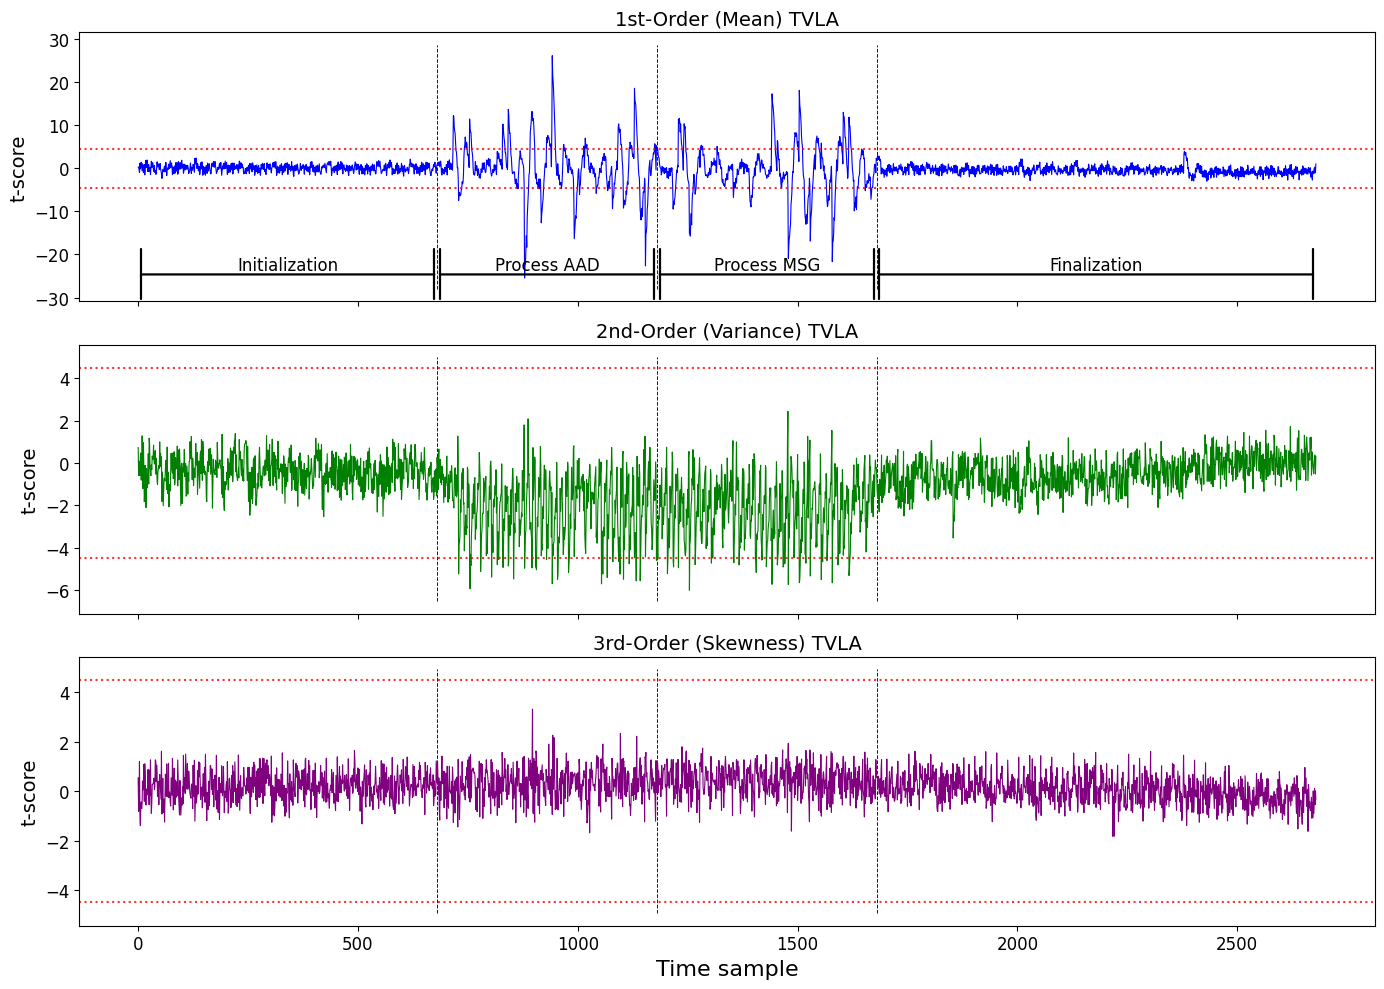

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------------------------
# Plot Configuration & Masking
# ---------------------------------------------------------------------------
threshold = 4.5
fs = 100e6         # 100 MHz
clock_freq = 10e6  # 10 MHz
samples_per_clock = int(fs / clock_freq)

n_samples = len(t1_curve)
print(f"Total samples per trace: {n_samples}")

# Skip the first 70 samples and realign x-axis
skip = 70
mask = np.arange(n_samples) >= skip
x = np.arange(n_samples)[mask] - skip

t1_use = t1_curve[mask]
t2_use = t2_curve[mask]
t3_use = t3_curve[mask]

# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
print("Generating 1st, 2nd, and 3rd Order TVLA plots...")
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Corrected vertical lines based on clock cycle calculations
vlines = np.array([610+skip, 1110+skip, 1610+skip])

def plot_tvla(ax, curve, order_name, color):
    ax.plot(x, curve, color=color, linewidth=0.8, label='t-scores')
    ax.axhline(y=threshold, color='red', linestyle=':', alpha=0.8)
    ax.axhline(y=-threshold, color='red', linestyle=':', alpha=0.8)
    ax.set_title(f"{order_name} TVLA", fontsize=14)
    ax.set_ylabel("t-score", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    
    # Align Vlines dynamically based on this subplot's limits
    ymin, ymax = ax.get_ylim()
    ax.vlines(vlines, ymin, ymax, linestyles='--', linewidth=0.7, alpha=0.9, color='black', zorder=0)
    return ymin, ymax

# Draw the 3 curves
ymin1, ymax1 = plot_tvla(axes[0], t1_use, "1st-Order (Mean)", 'blue')
plot_tvla(axes[1], t2_use, "2nd-Order (Variance)", 'green')
plot_tvla(axes[2], t3_use, "3rd-Order (Skewness)", 'purple')

# ----- Parentesi orizzontali interne (Braces) on the TOP subplot -----
def add_brace(ax, x0, x1, y, label, lw=1.6, fs=12):
    brace = FancyArrowPatch((x0, y), (x1, y),
                            arrowstyle='|-|', mutation_scale=18,
                            lw=lw, color='black', clip_on=True, zorder=3)
    ax.add_patch(brace)
    ax.text((x0 + x1) / 2.0, y, label, ha='center', va='bottom', fontsize=fs, zorder=3)

yr = ymax1 - ymin1
y_brace = ymin1 + 0.06 * yr  # Adjust vertical spacing inside the plot

xmax = x[-1]
spans = [
    (0,          vlines[0],  "Initialization"),
    (vlines[0],  vlines[1],  "Process AAD"),
    (vlines[1],  vlines[2],  "Process MSG"),
    (vlines[2],  xmax,       "Finalization"),
]

for x0, x1, lab in spans:
    if x1 > x0:
        add_brace(axes[0], x0, x1, y_brace, lab)

# Formatting
axes[2].set_xlabel('Time sample', fontsize=16)
plt.tight_layout()
plt.show()

## Bivariate (2nd-Order) TVLA: Initialization Phase

In a masked hardware implementation, the individual shares of a secret value are often processed concurrently within the same clock cycle. The different shares of a sensitive variable might be processed ($leak$) at different instants within the clock cycle. If those shares are processed or recombine within the same logical operation, their combined leakage will occur within the same clock cycle.

In our capture setup, the oscilloscope's **sampling frequency is 10 times higher than the target device's clock frequency**. This means a single clock cycle spans approximately 10 sample points on our traces.

We perform a **Bivariate TVLA** by combining each sample $t$ with its neighboring samples $t+d$ up to a maximum delay of 9 ($d \in \{0, 1, \dots, 9\}$). (2nd-order leakage)

The procedure for creating the synthetic bivariate traces is as follows:
1. **Mean-Centering:** Subtract the global mean from the raw traces.
   $$T'_t = T_t - \mu_t$$
2. **Combination (Multiplication):** Multiply the centered point at time $t$ with the centered point at time $t+d$.
   $$S_{t, d} = T'_t \times T'_{t+d}$$
3. **T-Test:** Perform a standard 1st-order Welch's t-test comparing the synthetic traces $S_{t, d}$ of the fixed dataset against the random dataset.

This operation is computationally intensive, so it is restricted to the **Initialization** phase (samples 70 to 670) which is the one protected.

Extracting Initialization phase (samples 70 to 670)...
Mean-centering traces...
Computing Bivariate TVLA for 10 intra-cycle delays...
Generating plot...


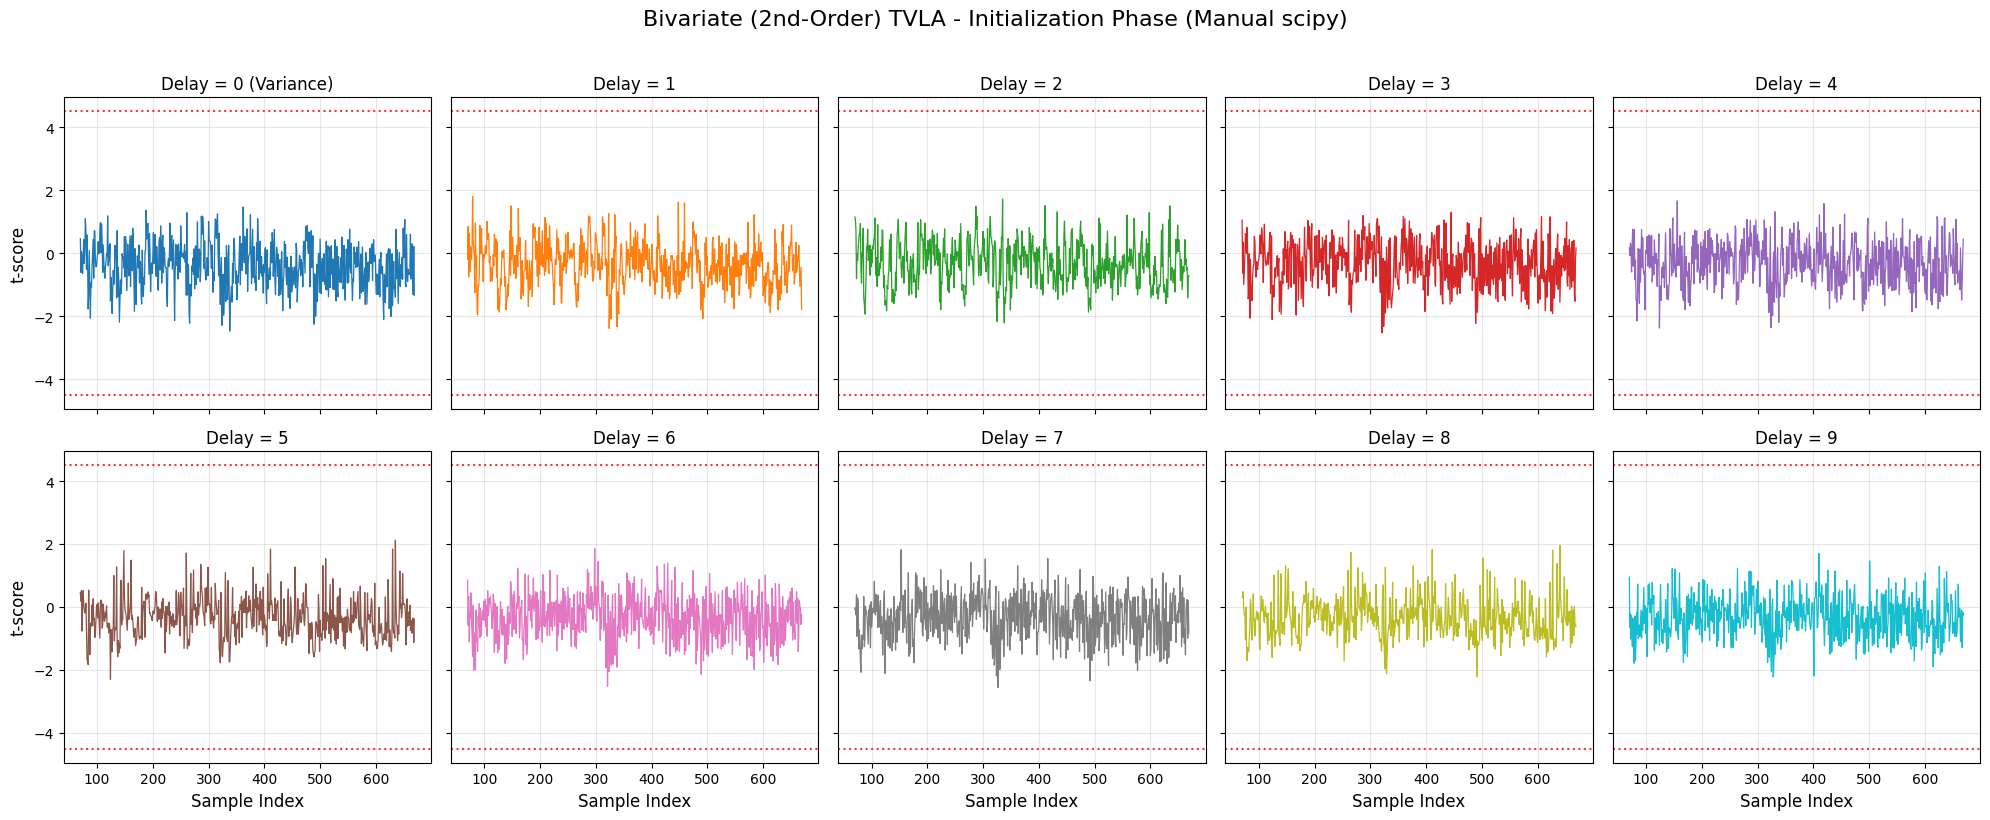

In [10]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Bivariate TVLA Configuration
# ---------------------------------------------------------------------------
start_idx = 70
end_idx = 670
window_len = end_idx - start_idx
max_delay = 10  # Delays from 0 to 9 (10 samples per clock)

print(f"Extracting Initialization phase (samples {start_idx} to {end_idx})...")

# 1. Slice the time samples (columns) safely using [:, start:end] 
#    and convert to float32 to prevent overflow during multiplication.
traces_f = traces_fixed[:, start_idx : end_idx + max_delay].astype(np.float32)
traces_r = traces_random[:, start_idx : end_idx + max_delay].astype(np.float32)

# ---------------------------------------------------------------------------
# Preprocessing: Mean-Centering
# ---------------------------------------------------------------------------
print("Mean-centering traces...")
# Compute the global mean across both sets for the extracted window
fix_mean = np.mean(np.vstack((traces_f)), axis=0)
fix_random = np.mean(np.vstack((traces_r)), axis=0)

centered_f = traces_f - fix_mean
centered_r = traces_r - fix_random

# ---------------------------------------------------------------------------
# Synthetic Trace Creation & T-Test
# ---------------------------------------------------------------------------
t_curves = []

print(f"Computing Bivariate TVLA for {max_delay} intra-cycle delays...")
for d in range(max_delay):
    # Multiply T'_t by T'_{t+d}
    synth_f = centered_f[:, :window_len] * centered_f[:, d : window_len + d]
    synth_r = centered_r[:, :window_len] * centered_r[:, d : window_len + d]
    
    # Run Welch's t-test
    t_stat, _ = ttest_ind(synth_f, synth_r, equal_var=False)
    t_curves.append(t_stat)

# ---------------------------------------------------------------------------
# Plotting (2x5 Grid)
# ---------------------------------------------------------------------------
print("Generating plot...")
# Create a 2x5 grid of subplots. sharex and sharey make comparison easier.
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to easily iterate over the 10 axes

x_axis = np.arange(start_idx, end_idx)
colors = plt.cm.tab10(np.linspace(0, 1, max_delay))

for d in range(max_delay):
    ax = axes[d]
    ax.plot(x_axis, t_curves[d], color=colors[d], linewidth=0.9)
    
    # TVLA Thresholds
    ax.axhline(y=4.5, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axhline(y=-4.5, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
    
    # Titles and Grids
    title = 'Delay = 0 (Variance)' if d == 0 else f'Delay = {d}'
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Set axis labels only on the outer edges to keep the grid clean
    if d >= 5:
        ax.set_xlabel('Sample Index', fontsize=12)
    if d % 5 == 0:
        ax.set_ylabel('t-score', fontsize=12)

fig.suptitle('Bivariate (2nd-Order) TVLA - Initialization Phase (Manual scipy)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Multivariate (2nd-Order) TVLA using SCALib MTtest

To evaluate 2nd-order intra-cycle leakage without manual matrix manipulation, we utilize `scalib.metrics.MTtest`. 

The `MTtest` class takes a dataset and a list of specific index combinations (Points of Interest, or POIs) and computes the higher-order Welch's t-test. It automatically handles the necessary mean-centering and normalization internally.

1. **Window Extraction:** We extract the Initialization phase (samples 70 to 670), plus an additional margin of 9 samples to accommodate the maximum intra-cycle delay. The traces are scaled and cast to `int16` as strictly required by `scalib`.
2. **POI Definition:** We define our POIs as an array of pairs $[x, x+d]$, where $x$ represents every sample in the Initialization phase, and $d \in \{0, \dots, 9\}$ represents the intra-cycle delay.
3. **Execution & Reshaping:** We pass the combined traces and labels to the `MTtest` model. The output is a flat array of t-scores, which we reshape into a $(10 \times \text{window\_len})$ grid to plot the individual delay curves.

Extracting Initialization phase (samples 70 to 670)...
Generating Points of Interest (POIs)...
Fitting MTtest model...
Generating plot...


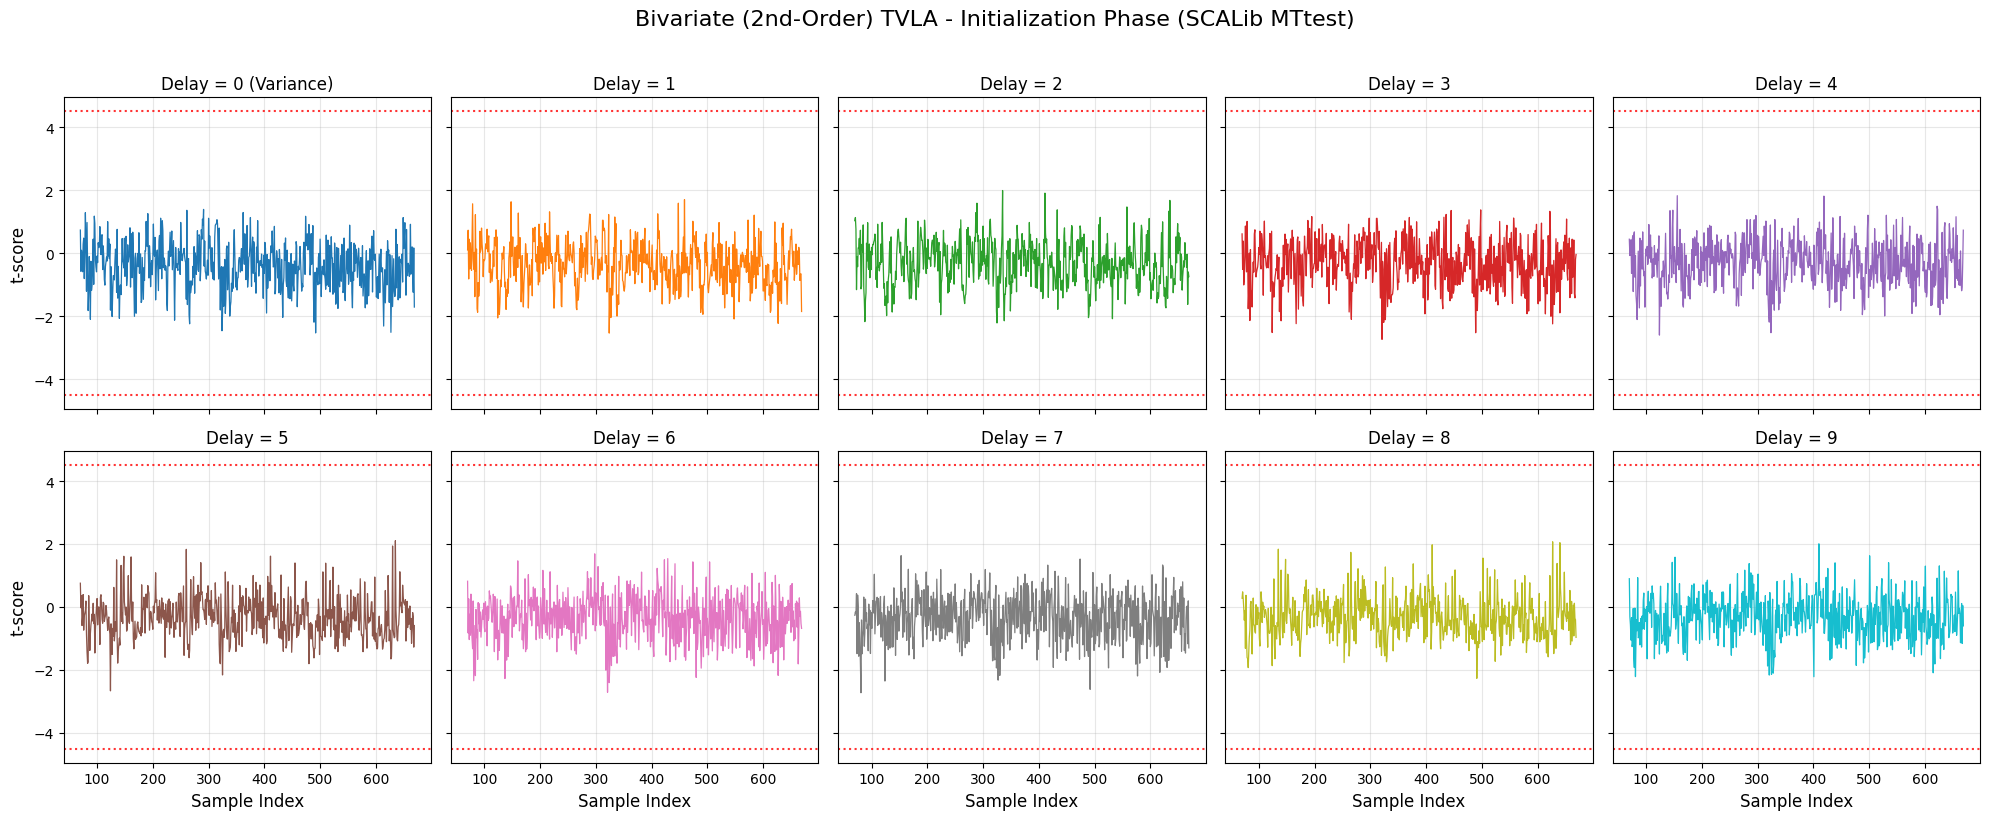

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scalib.metrics import MTtest

# ---------------------------------------------------------------------------
# Multivariate TVLA Configuration
# ---------------------------------------------------------------------------
start_idx = 70
end_idx = 670
window_len = end_idx - start_idx
max_delay = 10  # Delays from 0 to 9 (10 samples per clock)

print(f"Extracting Initialization phase (samples {start_idx} to {end_idx})...")

# SCALib requires int16. Scale floats if necessary to preserve waveform shape.
scale_factor = 1000.0 if all_traces.dtype in [np.float64, np.float32] else 1.0

traces_f_int = (traces_fixed[:, start_idx : end_idx + max_delay] * scale_factor).astype(np.int16)
traces_r_int = (traces_random[:, start_idx : end_idx + max_delay] * scale_factor).astype(np.int16)

# SCALib's MTtest expects a single combined trace array and a 1D array of class labels
combined_traces = np.vstack((traces_f_int, traces_r_int))
labels = np.concatenate((
    np.zeros(len(traces_f_int), dtype=np.uint16),
    np.ones(len(traces_r_int), dtype=np.uint16)
))

# ---------------------------------------------------------------------------
# POI Definition
# ---------------------------------------------------------------------------
print("Generating Points of Interest (POIs)...")
# We loop 'd' first, then 'x', so the resulting t-scores will be grouped by delay.
pois_list = [[x, x + d] for d in range(max_delay) for x in range(window_len)]

# SCALib expects POIs in shape (d, n_pois)
pois_array = np.array(pois_list, dtype=np.uint32).T 

# ---------------------------------------------------------------------------
# SCALib MTtest Execution
# ---------------------------------------------------------------------------
print("Fitting MTtest model...")
mttest = MTtest(d=2, pois=pois_array)
mttest.fit_u(combined_traces, labels)

# Retrieve the flat array of t-scores
flat_t_scores = mttest.get_ttest()

# Reshape into (10 delays x 600 samples)
t_curves = flat_t_scores.reshape((max_delay, window_len))

# ---------------------------------------------------------------------------
# Plotting (2x5 Grid)
# ---------------------------------------------------------------------------
print("Generating plot...")
# Create a 2x5 grid of subplots. sharex and sharey make comparison easier.
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to easily iterate over the 10 axes

x_axis = np.arange(start_idx, end_idx)
colors = plt.cm.tab10(np.linspace(0, 1, max_delay))

for d in range(max_delay):
    ax = axes[d]
    ax.plot(x_axis, t_curves[d], color=colors[d], linewidth=0.9)
    
    # TVLA Thresholds
    ax.axhline(y=4.5, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axhline(y=-4.5, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
    
    # Titles and Grids
    title = 'Delay = 0 (Variance)' if d == 0 else f'Delay = {d}'
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Set axis labels only on the outer edges to keep the grid clean
    if d >= 5:
        ax.set_xlabel('Sample Index', fontsize=12)
    if d % 5 == 0:
        ax.set_ylabel('t-score', fontsize=12)

fig.suptitle('Bivariate (2nd-Order) TVLA - Initialization Phase (SCALib MTtest)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Extracting traces for bivariate analysis...
Generating Points of Interest (POIs)...
Fitting MTtest model...
Generating Heatmap...


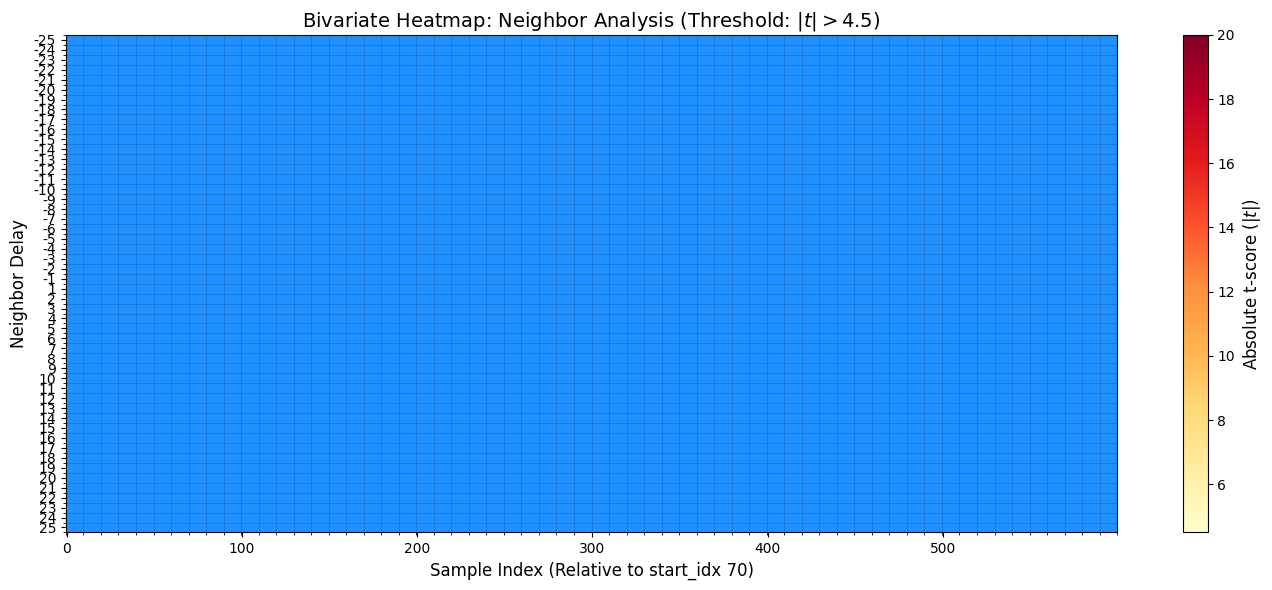

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scalib.metrics import MTtest

# ===========================================================================
# 1. COMPUTATION SECTION
# ===========================================================================

# Setup our target window and delays
start_idx = 70      # The absolute start of your region of interest
start_idx = 70
window_len = 600    # We want 100 samples (from start_idx to start_idx + 100)
delays = [d for d in range(-25, 26) if d != 0]

print(f"Extracting traces for bivariate analysis...")

# SCALib requires int16. Scale floats if necessary.
scale_factor = 1000.0 if all_traces.dtype in [np.float64, np.float32] else 1.0

# IMPORTANT: We need a "buffer" of 25 samples before start_idx and 25 after the window
# so we don't try to index negative or out-of-bounds array elements.
buffer_start = start_idx - 25
buffer_end = start_idx + window_len + 25

traces_f_int = (traces_fixed[:, buffer_start:buffer_end] * scale_factor).astype(np.int16)
traces_r_int = (traces_random[:, buffer_start:buffer_end] * scale_factor).astype(np.int16)

combined_traces = np.vstack((traces_f_int, traces_r_int))
labels = np.concatenate((
    np.zeros(len(traces_f_int), dtype=np.uint16),
    np.ones(len(traces_r_int), dtype=np.uint16)
))

print("Generating Points of Interest (POIs)...")
pois_list = []
# Since we sliced with a buffer of 5, the "0th" sample of our target window 
# is actually at index 5 in the combined_traces array.
base_offset = 25 

for d in delays:
    for x in range(window_len):
        # We pair sample x with sample x+d
        pois_list.append([base_offset + x, base_offset + x + d])

# SCALib expects POIs in shape (d, n_pois)
pois_array = np.array(pois_list, dtype=np.uint32).T 

print("Fitting MTtest model...")
mttest = MTtest(d=2, pois=pois_array)
mttest.fit_u(combined_traces, labels)

# Retrieve the flat array of t-scores and take the absolute value
flat_t_scores = np.abs(mttest.get_ttest())

# Reshape into a 2D grid: (10 delays, 100 samples)
t_matrix = flat_t_scores.reshape((len(delays), window_len))


# ===========================================================================
# 2. PLOTTING SECTION
# ===========================================================================

print("Generating Heatmap...")

# Mask the array: we hide any values <= 4.5 so we can color the background blue
masked_t = np.ma.masked_where(t_matrix <= 4.5, t_matrix)

fig, ax = plt.subplots(figsize=(14, 6))

# Set the background color for cells where the t-score is <= 4.5 (No Leakage)
ax.set_facecolor('dodgerblue') 

# Plot the heatmap for values > 4.5 (Leakage)
# cmap 'YlOrRd' creates a Yellow -> Orange -> Red gradient. 
# vmax=20 sets the ceiling for the deep red color.
heatmap = ax.imshow(masked_t, cmap='YlOrRd', vmin=4.5, vmax=20, aspect='auto')

# Configure Axes
ax.set_yticks(np.arange(len(delays)))
ax.set_yticklabels(delays)
ax.set_xlabel(f'Sample Index (Relative to start_idx {start_idx})', fontsize=12)
ax.set_ylabel('Neighbor Delay', fontsize=12)
ax.set_title('Bivariate Heatmap: Neighbor Analysis (Threshold: $|t| > 4.5$)', fontsize=14)

# Add a colorbar to explain the Yellow->Red gradient
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Absolute t-score ($|t|$)', fontsize=12)

# Optional: Add a subtle grid to delineate the blocks
ax.set_xticks(np.arange(-0.5, window_len, 10), minor=True)
ax.set_yticks(np.arange(-0.5, len(delays), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5, alpha=0.2)

plt.tight_layout()
plt.show()